# Articulated Agents Tutorial
Exploring Fetch + Spot robots in Habitat. Covers movement, arm control, physics, object picking, custom actions, and multi-agent.

In [1]:
%%bash
# Create symlinks so tutorial code paths resolve
mkdir -p /content/data/objects /content/data/robots
ln -sfn /content/drive/MyDrive/HabitatData/versioned_data/hab3_bench_assets /content/data/hab3_bench_assets
ln -sfn /content/drive/MyDrive/HabitatData/versioned_data/ycb /content/data/objects/ycb
ln -sfn /content/drive/MyDrive/HabitatData/versioned_data/hab_fetch /content/data/robots/hab_fetch
ln -sfn /content/drive/MyDrive/HabitatData/scene_datasets /content/data/scene_datasets 2>/dev/null || true

echo "Checking key files..."
ls /content/data/robots/hab_fetch/robots/hab_fetch.urdf 2>/dev/null || echo "Fetch URDF NOT FOUND"
ls /content/data/hab3_bench_assets/hab3-hssd/scenes/103997919_171031233.scene_instance.json 2>/dev/null || echo "Scene NOT FOUND"
ls /content/data/objects/ycb/configs 2>/dev/null | head -3 || echo "YCB NOT FOUND"

Checking key files...
/content/data/robots/hab_fetch/robots/hab_fetch.urdf
/content/data/hab3_bench_assets/hab3-hssd/scenes/103997919_171031233.scene_instance.json
002_master_chef_can.object_config.json
003_cracker_box.object_config.json
004_sugar_box.object_config.json


In [2]:
%%bash
# EGL setup for headless GPU rendering
cat > /tmp/nvidia_egl.json << 'EOF'
{
    "file_format_version" : "1.0.0",
    "ICD" : {
        "library_path" : "libEGL_nvidia.so.0"
    }
}
EOF
echo "EGL config ready"

EGL config ready


## 2. Helper file — configs and env init

In [28]:
%%bash
cat > /content/robot_utils.py << 'PYEOF'
import matplotlib
matplotlib.use("Agg")
import habitat_sim
import magnum as mn
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import os, gzip, json
from omegaconf import OmegaConf
from matplotlib import pyplot as plt

from habitat.tasks.rearrange.rearrange_sim import RearrangeSim
from habitat.datasets.rearrange.rearrange_dataset import RearrangeEpisode
from habitat_sim.utils import viz_utils as vut
from habitat_sim.physics import JointMotorSettings, MotionType
from habitat.config.default_structured_configs import (
    ThirdRGBSensorConfig, HeadRGBSensorConfig, HeadPanopticSensorConfig,
    SimulatorConfig, AgentConfig, HabitatSimV0Config,
    TaskConfig, EnvironmentConfig, DatasetConfig, HabitatConfig,
    ArmActionConfig, BaseVelocityActionConfig, OracleNavActionConfig, ActionConfig,
)
from habitat.core.env import Env

DATA_PATH = "/content/data"
EPISODE_FILE = os.path.join(DATA_PATH, "hab3_bench_assets/episode_datasets/small_large.json.gz")

def make_sim_cfg(agent_dict):
    sim_cfg = SimulatorConfig(type="RearrangeSim-v0")
    sim_cfg.habitat_sim_v0.enable_hbao = True
    sim_cfg.habitat_sim_v0.enable_physics = True
    sim_cfg.scene = os.path.join(DATA_PATH, "hab3_bench_assets/hab3-hssd/scenes/103997919_171031233.scene_instance.json")
    sim_cfg.scene_dataset = os.path.join(DATA_PATH, "hab3_bench_assets/hab3-hssd/hab3-hssd.scene_dataset_config.json")
    sim_cfg.additional_object_paths = [os.path.join(DATA_PATH, "objects/ycb/configs/")]
    cfg = OmegaConf.create(sim_cfg)
    cfg.agents = agent_dict
    cfg.agents_order = list(cfg.agents.keys())
    return cfg

def init_rearrange_sim(agent_dict, load_episode=True):
    """Create a RearrangeSim with optional episode (required for step to work)."""
    sim_cfg = make_sim_cfg(agent_dict)
    cfg = OmegaConf.create(sim_cfg)
    sim = RearrangeSim(cfg)
    sim.agents_mgr.on_new_scene()

    if load_episode:
        with gzip.open(EPISODE_FILE, "rt") as f:
            eps = json.load(f)
        episode = RearrangeEpisode(**eps["episodes"][0])
        sim.reconfigure(cfg, ep_info=episode)
        sim.reset()

    # Add a fixed world camera (doesn't follow agent)
    camera_spec = habitat_sim.CameraSensorSpec()
    camera_spec.sensor_type = habitat_sim.SensorType.COLOR
    camera_spec.uuid = "scene_camera_rgb"
    sim.add_sensor(camera_spec, 0)
    return sim

def make_hab_cfg(agent_dict, action_dict):
    sim_cfg = make_sim_cfg(agent_dict)
    task_cfg = TaskConfig(type="RearrangeEmptyTask-v0")
    task_cfg.actions = action_dict
    env_cfg = EnvironmentConfig()
    dataset_cfg = DatasetConfig(
        type="RearrangeDataset-v0",
        data_path=EPISODE_FILE,
    )
    hab_cfg = HabitatConfig()
    hab_cfg.environment = env_cfg
    hab_cfg.task = task_cfg
    hab_cfg.dataset = dataset_cfg
    hab_cfg.simulator = sim_cfg
    hab_cfg.simulator.seed = hab_cfg.seed
    return hab_cfg

def init_rearrange_env(agent_dict, action_dict):
    hab_cfg = make_hab_cfg(agent_dict, action_dict)
    res_cfg = OmegaConf.create(hab_cfg)
    return Env(res_cfg)

def fetch_agent():
    cfg = AgentConfig()
    cfg.articulated_agent_urdf = os.path.join(DATA_PATH, "robots/hab_fetch/robots/hab_fetch.urdf")
    cfg.articulated_agent_type = "FetchRobot"
    cfg.sim_sensors = {
        "third_rgb": ThirdRGBSensorConfig(),
        "head_rgb": HeadRGBSensorConfig(),
    }
    return cfg

def spot_agent():
    cfg = AgentConfig()
    cfg.articulated_agent_urdf = os.path.join(DATA_PATH, "robots/hab_spot_arm/urdf/hab_spot_arm.urdf")
    cfg.articulated_agent_type = "SpotRobot"
    cfg.sim_sensors = {
        "third_rgb": ThirdRGBSensorConfig(),
        "head_rgb": HeadRGBSensorConfig(),
    }
    return cfg

print("robot_utils.py ready")
PYEOF

## 3. Initialize Fetch and take first observation

In [4]:
%%bash
source /opt/conda/etc/profile.d/conda.sh && conda activate habitatEnv
cd /content && export MPLBACKEND=Agg
export __EGL_VENDOR_LIBRARY_FILENAMES=/tmp/nvidia_egl.json
export LD_LIBRARY_PATH=$(dirname $(find /usr -name "libEGL_nvidia.so.0" 2>/dev/null | head -1)):$LD_LIBRARY_PATH
export NVIDIA_DRIVER_CAPABILITIES=all

python - <<'PY'
from robot_utils import *

agent_dict = {"main_agent": fetch_agent()}
sim = init_rearrange_sim(agent_dict)

init_pos = mn.Vector3(-5.5, 0, -1.5)
art_agent = sim.articulated_agent
art_agent.sim_obj.motion_type = MotionType.KINEMATIC
print("Original pos:", art_agent.base_pos)
art_agent.base_pos = init_pos
print("New pos:", art_agent.base_pos)
_ = sim.step({})

obs = sim.get_sensor_observations()
print("Sensors:", list(obs.keys()))

fig, ax = plt.subplots(1, len(obs), figsize=(15, 4))
for i, name in enumerate(obs.keys()):
    ax[i].imshow(obs[name])
    ax[i].set_axis_off()
    ax[i].set_title(name)
plt.savefig("/content/fetch_init.png", dpi=120, bbox_inches="tight")
print("Cameras:", list(art_agent.params.cameras.keys()))
sim.close()
PY

Renderer: Tesla T4/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 580.82.07
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-size-in-bits
robot_utils.py ready
Original pos: Vector(0, 0, 0)
New pos: Vector(

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
pybullet build time: Jan 29 2025 23:20:52
[18:37:40:218290]:[Warning]:[Metadata] SceneDatasetAttributes.cpp(107)::addNewSceneInstanceToDataset : Dataset : 'hab3-hssd' : Lighting Layout Attributes '/content/data/hab3_bench_assets/hab3-hssd/scenes/103997919_171031233.scene_instance.json' specified in Scene Attributes but does not exist in dataset, so creating default.
[18:37:40:221421]:[Warning]:[Scene] SemanticScene.h(331)::checkFileExists : ::loadSemanticSceneDescriptor: File `../hssd-hab_semantic_lexicon.json` does not exist.  Aborting load.
[18:37:40:221465]:[Warning]:[Scene] SemanticScene.cpp(123)::loadSemanticSceneDescriptor 

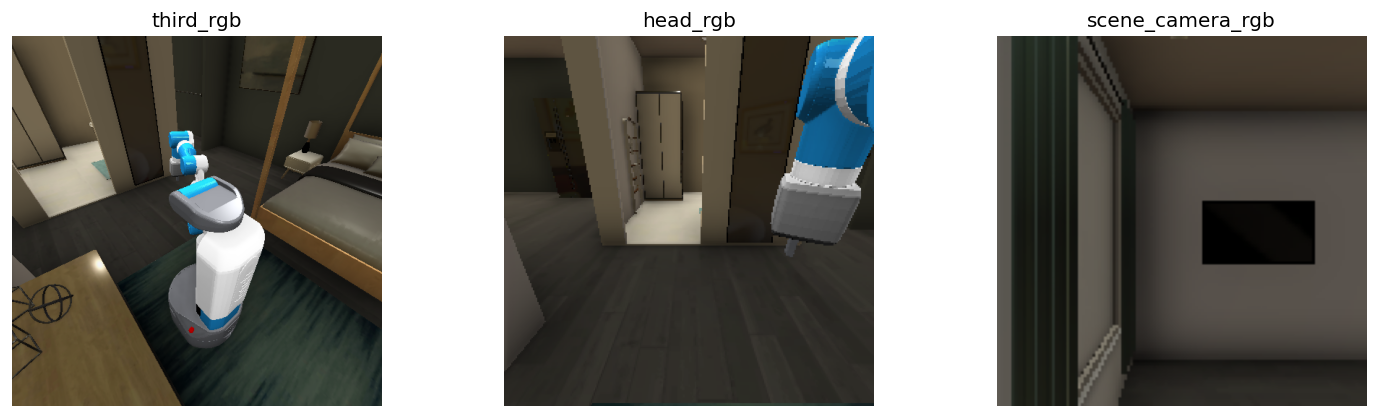

In [5]:
from IPython.display import Image, display
display(Image("/content/fetch_init.png"))

## 4. Move the agent base (translate + rotate)

In [10]:
%%bash
source /opt/conda/etc/profile.d/conda.sh && conda activate habitatEnv
cd /content && export MPLBACKEND=Agg
export __EGL_VENDOR_LIBRARY_FILENAMES=/tmp/nvidia_egl.json
export LD_LIBRARY_PATH=$(dirname $(find /usr -name "libEGL_nvidia.so.0" 2>/dev/null | head -1)):$LD_LIBRARY_PATH
export NVIDIA_DRIVER_CAPABILITIES=all

python - <<'PY'
from robot_utils import *
import imageio

agent_dict = {"main_agent": fetch_agent()}
sim = init_rearrange_sim(agent_dict)

init_pos = mn.Vector3(-5.5, 0, -1.5)
art_agent = sim.articulated_agent
art_agent.sim_obj.motion_type = MotionType.KINEMATIC
art_agent.base_pos = init_pos

num_iter = 100
pos_delta = mn.Vector3(0.02, 0, 0)
rot_delta = np.pi / (8 * num_iter)

third_frames, scene_frames = [], []
sim.reset()
art_agent.base_pos = init_pos
for _ in range(num_iter):
    art_agent.base_pos = art_agent.base_pos + pos_delta
    art_agent.base_rot = art_agent.base_rot + rot_delta
    sim.step({})
    obs = sim.get_sensor_observations()
    third_frames.append(obs["third_rgb"][:, :, :3])
    # scene_frames.append(obs["scene_camera_rgb"][:, :, :3])

for name, frames in [("third", third_frames)]:
    w = imageio.get_writer(f"/content/fetch_move_{name}.mp4", fps=15)
    for f in frames:
        w.append_data(f)
    w.close()

print(f"Saved {len(third_frames)} frames per video")
sim.close()
PY

Renderer: Tesla T4/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 580.82.07
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-size-in-bits
robot_utils.py ready
Saved 100 frames per video


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
pybullet build time: Jan 29 2025 23:20:52
[18:45:28:955312]:[Warning]:[Metadata] SceneDatasetAttributes.cpp(107)::addNewSceneInstanceToDataset : Dataset : 'hab3-hssd' : Lighting Layout Attributes '/content/data/hab3_bench_assets/hab3-hssd/scenes/103997919_171031233.scene_instance.json' specified in Scene Attributes but does not exist in dataset, so creating default.
[18:45:28:956281]:[Warning]:[Scene] SemanticScene.h(331)::checkFileExists : ::loadSemanticSceneDescriptor: File `../hssd-hab_semantic_lexicon.json` does not exist.  Aborting load.
[18:45:28:956407]:[Warning]:[Scene] SemanticScene.cpp(123)::loadSemanticSceneDescriptor 

In [12]:
from IPython.display import Video, display
print("Third person (follows robot):")
display(Video("/content/fetch_move_third.mp4", embed=True, width=500))
# print("Scene camera (fixed):")
# display(Video("/content/fetch_move_scene.mp4", embed=True, width=500))

Third person (follows robot):


## 5. Control arm joints — interpolate from min to max

In [13]:
%%bash
source /opt/conda/etc/profile.d/conda.sh && conda activate habitatEnv
cd /content && export MPLBACKEND=Agg
export __EGL_VENDOR_LIBRARY_FILENAMES=/tmp/nvidia_egl.json
export LD_LIBRARY_PATH=$(dirname $(find /usr -name "libEGL_nvidia.so.0" 2>/dev/null | head -1)):$LD_LIBRARY_PATH
export NVIDIA_DRIVER_CAPABILITIES=all

python - <<'PY'
from robot_utils import *
import imageio

agent_dict = {"main_agent": fetch_agent()}
sim = init_rearrange_sim(agent_dict)

init_pos = mn.Vector3(-5.5, 0, -1.5)
art_agent = sim.articulated_agent
art_agent.sim_obj.motion_type = MotionType.KINEMATIC
art_agent.base_pos = init_pos
sim.reset()
art_agent.base_pos = init_pos

lower = art_agent.arm_joint_limits[0].copy()
lower[lower == -np.inf] = 0
upper = art_agent.arm_joint_limits[1].copy()
upper[upper == np.inf] = 0
print(f"Arm joints: {len(lower)}")
print(f"Lower: {lower}")
print(f"Upper: {upper}")

frames = []
num_iter = 100
for i in range(num_iter):
    alpha = i / num_iter
    joints = upper * alpha + lower * (1 - alpha)
    art_agent.arm_joint_pos = joints
    sim.step({})
    obs = sim.get_sensor_observations()
    frames.append(obs["third_rgb"][:, :, :3])
    if i in [0, num_iter - 1]:
        print(f"Step {i}: end effector = {art_agent.ee_transform().translation}")

w = imageio.get_writer("/content/fetch_arm.mp4", fps=15)
for f in frames:
    w.append_data(f)
w.close()
print(f"Saved {len(frames)} frames")
sim.close()
PY

Renderer: Tesla T4/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 580.82.07
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-size-in-bits
robot_utils.py ready
Arm joints: 7
Lower: [-1.6056 -1.221   0.     

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
pybullet build time: Jan 29 2025 23:20:52
[19:11:05:378959]:[Warning]:[Metadata] SceneDatasetAttributes.cpp(107)::addNewSceneInstanceToDataset : Dataset : 'hab3-hssd' : Lighting Layout Attributes '/content/data/hab3_bench_assets/hab3-hssd/scenes/103997919_171031233.scene_instance.json' specified in Scene Attributes but does not exist in dataset, so creating default.
[19:11:05:381337]:[Warning]:[Scene] SemanticScene.h(331)::checkFileExists : ::loadSemanticSceneDescriptor: File `../hssd-hab_semantic_lexicon.json` does not exist.  Aborting load.
[19:11:05:381382]:[Warning]:[Scene] SemanticScene.cpp(123)::loadSemanticSceneDescriptor 

In [14]:
from IPython.display import Video, display
display(Video("/content/fetch_arm.mp4", embed=True, width=600))

## 6. Dynamic vs Kinematic — drop the robot from height
Unlike humanoids, Fetch has proper collision shapes so it actually lands on the floor.

In [23]:
%%bash
source /opt/conda/etc/profile.d/conda.sh && conda activate habitatEnv
cd /content && export MPLBACKEND=Agg
export __EGL_VENDOR_LIBRARY_FILENAMES=/tmp/nvidia_egl.json
export LD_LIBRARY_PATH=$(dirname $(find /usr -name "libEGL_nvidia.so.0" 2>/dev/null | head -1)):$LD_LIBRARY_PATH
export NVIDIA_DRIVER_CAPABILITIES=all

python - <<'PY'
from robot_utils import *
import imageio

agent_dict = {"main_agent": fetch_agent()}
sim = init_rearrange_sim(agent_dict)
art_agent = sim.articulated_agent
art_agent._fixed_base = False
sim.agents_mgr.on_new_scene()
art_agent.sim_obj.motion_type = MotionType.DYNAMIC

init_pos = mn.Vector3(-5.5, 0, -1.5)
art_agent.base_pos = init_pos + mn.Vector3(0, 1.5, 0)
print(f"Dropped at y={art_agent.base_pos.y:.2f}")

frames = []
fps = 60
dt = 1.0 / fps
for i in range(120):
    sim.step_physics(dt)
    sim.step({})
    obs = sim.get_sensor_observations()
    frames.append(obs["third_rgb"][:, :, :3])
    if i % 30 == 0:
        print(f"Step {i}: y = {art_agent.base_pos.y:.3f}")

w = imageio.get_writer("/content/fetch_dynamic_drop.mp4", fps=30)
for f in frames:
    w.append_data(f)
w.close()
print(f"Saved {len(frames)} frames. Final y: {art_agent.base_pos.y:.3f}")
sim.close()
PY

Renderer: Tesla T4/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 580.82.07
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-size-in-bits
robot_utils.py ready
Dropped at y=1.50
Step 0: y = 1.487
Step 30: y

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
pybullet build time: Jan 29 2025 23:20:52
[19:16:10:916460]:[Warning]:[Metadata] SceneDatasetAttributes.cpp(107)::addNewSceneInstanceToDataset : Dataset : 'hab3-hssd' : Lighting Layout Attributes '/content/data/hab3_bench_assets/hab3-hssd/scenes/103997919_171031233.scene_instance.json' specified in Scene Attributes but does not exist in dataset, so creating default.
[19:16:10:917592]:[Warning]:[Scene] SemanticScene.h(331)::checkFileExists : ::loadSemanticSceneDescriptor: File `../hssd-hab_semantic_lexicon.json` does not exist.  Aborting load.
[19:16:10:917651]:[Warning]:[Scene] SemanticScene.cpp(123)::loadSemanticSceneDescriptor 

In [24]:
from IPython.display import Video, display
display(Video("/content/fetch_dynamic_drop.mp4", embed=True, width=600))

## 7. Pick up an object — grasp manager
Load episode with objects, teleport near one, snap it to the robot's arm.

In [17]:
%%bash
source /opt/conda/etc/profile.d/conda.sh && conda activate habitatEnv
cd /content && export MPLBACKEND=Agg
export __EGL_VENDOR_LIBRARY_FILENAMES=/tmp/nvidia_egl.json
export LD_LIBRARY_PATH=$(dirname $(find /usr -name "libEGL_nvidia.so.0" 2>/dev/null | head -1)):$LD_LIBRARY_PATH
export NVIDIA_DRIVER_CAPABILITIES=all

python - <<'PY'
from robot_utils import *
from habitat.datasets.rearrange.rearrange_dataset import RearrangeEpisode
import imageio, gzip, json

agent_dict = {"main_agent": fetch_agent()}
sim = init_rearrange_sim(agent_dict)

# Load an episode with pre-placed objects
episode_file = "/content/data/hab3_bench_assets/episode_datasets/small_large.json.gz"
with gzip.open(episode_file, "rt") as f:
    eps = json.load(f)
rearrange_episode = RearrangeEpisode(**eps["episodes"][0])

art_agent = sim.articulated_agent
art_agent._fixed_base = True
sim.agents_mgr.on_new_scene()
sim.reconfigure(sim.habitat_config, ep_info=rearrange_episode)
sim.reset()
art_agent.sim_obj.motion_type = MotionType.KINEMATIC

init_pos = mn.Vector3(-5.5, 0, -1.5)
sim.articulated_agent.base_pos = init_pos
sim.step({})

# Find an object to pick
rom = sim.get_rigid_object_manager()
obj_id = sim.scene_obj_ids[0]
first_object = rom.get_object_by_id(obj_id)
object_trans = first_object.translation
print(f"{first_object.handle} at {object_trans}")

# Teleport near the object facing it
sample = sim.pathfinder.get_random_navigable_point_near(
    circle_center=object_trans, radius=0.6, island_index=-1
)
vec = object_trans - sample
angle = np.arctan2(-vec[2], vec[0])
sim.articulated_agent.base_pos = sim.pathfinder.snap_point(sample)
sim.articulated_agent.base_rot = angle
sim.step({})

# Grasp
grasp_mgr = sim.agents_mgr[0].grasp_mgrs[0]
grasp_mgr.snap_to_obj(obj_id)
sim.step({})

# Walk forward carrying the object
frames = []
for _ in range(70):
    forward = art_agent.base_transformation.transform_vector(mn.Vector3(-1, 0, 1))
    candidate = art_agent.base_pos + forward * 0.02

    # keep robot on navmesh
    candidate = sim.pathfinder.snap_point(candidate)

    # guard in case snap_point fails / returns invalid
    if np.isfinite(candidate[0]) and np.isfinite(candidate[1]) and np.isfinite(candidate[2]):
        art_agent.base_pos = candidate
        
    obs = sim.step({})
    frames.append(obs["third_rgb"][:, :, :3])

# Drop
grasp_mgr.desnap()
for _ in range(20):
    obs = sim.step({})
    frames.append(obs["third_rgb"][:, :, :3])

w = imageio.get_writer("/content/fetch_pick_drop.mp4", fps=15)
for f in frames:
    w.append_data(f)
w.close()
print(f"Saved {len(frames)} frames")
sim.close()
PY

Renderer: Tesla T4/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 580.82.07
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-size-in-bits
robot_utils.py ready
002_master_chef_can_:0000 at Vector(-7.16471, 

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
pybullet build time: Jan 29 2025 23:20:52
[00:41:08:579901]:[Warning]:[Metadata] SceneDatasetAttributes.cpp(107)::addNewSceneInstanceToDataset : Dataset : 'hab3-hssd' : Lighting Layout Attributes '/content/data/hab3_bench_assets/hab3-hssd/scenes/103997919_171031233.scene_instance.json' specified in Scene Attributes but does not exist in dataset, so creating default.
[00:41:08:581117]:[Warning]:[Scene] SemanticScene.h(331)::checkFileExists : ::loadSemanticSceneDescriptor: File `../hssd-hab_semantic_lexicon.json` does not exist.  Aborting load.
[00:41:08:581177]:[Warning]:[Scene] SemanticScene.cpp(123)::loadSemanticSceneDescriptor 

In [18]:
from IPython.display import Video, display
display(Video("/content/fetch_pick_drop.mp4", embed=True, width=600))

## 8. Agent Actions — BaseVelocity, OracleNav, MagicGrasp
Higher-level abstraction over direct position manipulation.

In [48]:
%%bash
source /opt/conda/etc/profile.d/conda.sh && conda activate habitatEnv
cd /content && export MPLBACKEND=Agg
export __EGL_VENDOR_LIBRARY_FILENAMES=/tmp/nvidia_egl.json
export LD_LIBRARY_PATH=$(dirname $(find /usr -name "libEGL_nvidia.so.0" 2>/dev/null | head -1)):$LD_LIBRARY_PATH
export NVIDIA_DRIVER_CAPABILITIES=all

python - <<'PY'
from robot_utils import *
import imageio

agent_dict = {"main_agent": fetch_agent()}
action_dict = {
    "oracle_magic_grasp_action": ArmActionConfig(type="MagicGraspAction"),
    "base_velocity_action": BaseVelocityActionConfig(),
    "oracle_coord_action": OracleNavActionConfig(type="OracleNavCoordinateAction", spawn_max_dist_to_obj=1.0),
}
env = init_rearrange_env(agent_dict, action_dict)

# See available actions
for name, space in env.action_space.items():
    print(name," ,, ", space)

env.reset()

# Navigate to an object using oracle
rom = env.sim.get_rigid_object_manager()
obj_id = env.sim.scene_obj_ids[0]
first_object = rom.get_object_by_id(obj_id)
object_trans = first_object.translation
print(f"Target: {first_object.handle}")

frames = []
agent_displ = np.inf
agent_rot = np.inf
step = 0
while (agent_displ > 1e-9 or agent_rot > 1e-9) and step < 500:
    prev_pos = env.sim.articulated_agent.base_pos
    prev_rot = env.sim.articulated_agent.base_rot
    action = {
        "action": "oracle_coord_action",
        "action_args": {
            "oracle_nav_lookat_action": object_trans,
            "mode": 1,
        },
    }
    obs = env.step(action)
    frames.append(obs["third_rgb"][:, :, :3])
    agent_displ = (env.sim.articulated_agent.base_pos - prev_pos).length()
    agent_rot = np.abs(env.sim.articulated_agent.base_rot - prev_rot)
    step += 1

# Wait a bit
for _ in range(20):
    obs = env.step({"action": (), "action_args": {}})
    frames.append(obs["third_rgb"][:, :, :3])

w = imageio.get_writer("/content/fetch_oracle_nav.mp4", fps=15)
for f in frames:
    w.append_data(f)
w.close()
print(f"Navigated in {step} steps, {len(frames)} frames")
env.close()
PY

Renderer: Tesla T4/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 580.82.07
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-size-in-bits
robot_utils.py ready
base_velocity_action  ,,  Dict(base_vel:Box(-2

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
pybullet build time: Jan 29 2025 23:20:52
2026-04-18 02:15:45,361 Initializing dataset RearrangeDataset-v0
2026-04-18 02:15:45,366 initializing sim RearrangeSim-v0
[02:15:46:701070]:[Warning]:[Metadata] SceneDatasetAttributes.cpp(107)::addNewSceneInstanceToDataset : Dataset : 'hab3-hssd' : Lighting Layout Attributes 'data/hab3_bench_assets/hab3-hssd/scenes/103997919_171031233.scene_instance.json' specified in Scene Attributes but does not exist in dataset, so creating default.
[02:15:46:702215]:[Warning]:[Scene] SemanticScene.h(331)::checkFileExists : ::loadSemanticSceneDescriptor: File `../hssd-hab_semantic_lexicon.json` does no

In [49]:
from IPython.display import Video, display
display(Video("/content/fetch_oracle_nav.mp4", embed=True, width=600))

## 9. Multi-agent: Fetch + Spot navigating together


In [23]:
%%bash
source /opt/conda/etc/profile.d/conda.sh && conda activate habitatEnv

if [ ! -d /content/drive/MyDrive/HabitatData/versioned_data/hab_spot_arm ]; then
    python -m habitat_sim.utils.datasets_download \
        --uids hab_spot_arm \
        --data-path /content/drive/MyDrive/HabitatData \
        --no-replace --no-prune 2>&1 | tail -5
fi

ln -sfn /content/drive/MyDrive/HabitatData/versioned_data/hab_spot_arm /content/data/robots/hab_spot_arm
ls /content/data/robots/hab_spot_arm/urdf/hab_spot_arm.urdf && echo "Spot URDF found"

    subprocess.check_call(split_command)
  File "/opt/conda/envs/habitatEnv/lib/python3.9/subprocess.py", line 373, in check_call
    raise CalledProcessError(retcode, cmd)
subprocess.CalledProcessError: Command '['git', 'clone', '--depth', '1', '--branch', 'v2.0', 'https://huggingface.co/datasets/ai-habitat/hab_spot_arm.git', '/content/drive/MyDrive/HabitatData/versioned_data/hab_spot_arm']' returned non-zero exit status 255.
git clone --depth 1 --branch v2.0 https://huggingface.co/datasets/ai-habitat/hab_spot_arm.git /content/drive/MyDrive/HabitatData/versioned_data/hab_spot_arm
/content/data/robots/hab_spot_arm/urdf/hab_spot_arm.urdf
Spot URDF found


In [50]:
%%bash
source /opt/conda/etc/profile.d/conda.sh && conda activate habitatEnv
cd /content && export MPLBACKEND=Agg
export __EGL_VENDOR_LIBRARY_FILENAMES=/tmp/nvidia_egl.json
export LD_LIBRARY_PATH=$(dirname $(find /usr -name "libEGL_nvidia.so.0" 2>/dev/null | head -1)):$LD_LIBRARY_PATH
export NVIDIA_DRIVER_CAPABILITIES=all

python - <<'PY'
from robot_utils import *
import imageio

# Build Fetch + Spot agents, prefix actions with agent name
agent_dict = {"agent_0": fetch_agent(), "agent_1": spot_agent()}

base_actions = {
    "oracle_magic_grasp_action": ArmActionConfig(type="MagicGraspAction"),
    "base_velocity_action": BaseVelocityActionConfig(),
    "oracle_coord_action": OracleNavActionConfig(type="OracleNavCoordinateAction", spawn_max_dist_to_obj=1.0),
}
multi_action_dict = {
    f"agent_{i}_{name}": cfg
    for name, cfg in base_actions.items()
    for i in range(2)
}

env = init_rearrange_env(agent_dict, multi_action_dict)
env.reset()

# Pick a target object and snap to nearest navigable point
rom = env.sim.get_rigid_object_manager()
target_obj = rom.get_object_by_id(env.sim.scene_obj_ids[0])
target = mn.Vector3(env.sim.pathfinder.snap_point(target_obj.translation))
print(f"Target: {target}")

# Both agents navigate to the target
a0 = env.sim.agents_mgr[0].articulated_agent
a1 = env.sim.agents_mgr[1].articulated_agent
target_np = np.array(target, dtype=np.float32)

frames = []
stopped_count = 0
for step in range(500):
    prev_a0 = mn.Vector3(a0.base_pos)
    prev_a1 = mn.Vector3(a1.base_pos)

    action = {
        "action": ("agent_0_oracle_coord_action", "agent_1_oracle_coord_action"),
        "action_args": {
            "agent_0_oracle_nav_coord_action": target_np,
            "agent_0_oracle_nav_lookat_action": target_np,
            "agent_0_mode": 2,
            "agent_1_oracle_nav_coord_action": target_np,
            "agent_1_oracle_nav_lookat_action": target_np,
            "agent_1_mode": 2,
        },
    }
    obs = env.step(action)
    frames.append(obs["agent_1_third_rgb"][:, :, :3])

    # Allow a grace period (30 steps) before checking stop condition
    if step < 30:
        continue
    if (a0.base_pos - prev_a0).length() < 1e-4 and (a1.base_pos - prev_a1).length() < 1e-4:
        stopped_count += 1
        if stopped_count >= 5:
            print(f"Both agents stopped at step {step}")
            break
    else:
        stopped_count = 0

writer = imageio.get_writer("/content/multi_agent_nav.mp4", fps=15)
for f in frames:
    writer.append_data(f)
writer.close()
print(f"Saved {len(frames)} frames")
env.close()
PY

Renderer: Tesla T4/PCIe/SSE2 by NVIDIA Corporation
OpenGL version: 4.6.0 NVIDIA 580.82.07
Using optional features:
    GL_ARB_vertex_array_object
    GL_ARB_separate_shader_objects
    GL_ARB_robustness
    GL_ARB_texture_storage
    GL_ARB_texture_view
    GL_ARB_framebuffer_no_attachments
    GL_ARB_invalidate_subdata
    GL_ARB_texture_storage_multisample
    GL_ARB_multi_bind
    GL_ARB_direct_state_access
    GL_ARB_get_texture_sub_image
    GL_ARB_texture_filter_anisotropic
    GL_KHR_debug
    GL_KHR_parallel_shader_compile
    GL_NV_depth_buffer_float
Using driver workarounds:
    no-forward-compatible-core-context
    nv-egl-incorrect-gl11-function-pointers
    no-layout-qualifiers-on-old-glsl
    nv-zero-context-profile-mask
    nv-implementation-color-read-format-dsa-broken
    nv-cubemap-inconsistent-compressed-image-size
    nv-cubemap-broken-full-compressed-image-query
    nv-compressed-block-size-in-bits
robot_utils.py ready
Target: Vector(-5.55847, 0.180179, -2.778)
Bot

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
pybullet build time: Jan 29 2025 23:20:52
2026-04-18 02:16:23,377 Initializing dataset RearrangeDataset-v0
2026-04-18 02:16:23,383 initializing sim RearrangeSim-v0
[02:16:24:691486]:[Warning]:[Metadata] SceneDatasetAttributes.cpp(107)::addNewSceneInstanceToDataset : Dataset : 'hab3-hssd' : Lighting Layout Attributes 'data/hab3_bench_assets/hab3-hssd/scenes/103997919_171031233.scene_instance.json' specified in Scene Attributes but does not exist in dataset, so creating default.
[02:16:24:692738]:[Warning]:[Scene] SemanticScene.h(331)::checkFileExists : ::loadSemanticSceneDescriptor: File `../hssd-hab_semantic_lexicon.json` does no

In [51]:
from IPython.display import Video, display
display(Video("/content/multi_agent_nav.mp4", embed=True, width=600))